# Healthcare Threat Intelligence Assessment

## Purpose

This notebook analyzes CISA Known Exploited Vulnerabilities added between
January 1, 2026, and June 30, 2026. It prioritizes vulnerabilities that may
be relevant to a fictional regional healthcare organization.

## Ethical Scope

This analysis uses public defensive-security information. It does not include
system scanning, exploitation, malware execution, unauthorized access, or
analysis of real patient information.

## Notebook Roadmap

1. Import and inspect the raw CISA KEV dataset
2. Clean and filter the study period
3. Conduct exploratory analysis
4. Classify healthcare and internet-facing relevance
5. Apply the vulnerability-prioritization model
6. Add manual operational-impact scores
7. Export the processed dataset
8. Research three priority vulnerabilities
9. Map supported behavior to MITRE ATT&CK
10. Present executive findings, limitations, and deliverables


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# The notebook looks for the raw CISA KEV file in common Colab and local locations.
candidate_files = [
    Path("/content/cisa_kev_catalog.csv"),
    Path("cisa_kev_catalog.csv"),
    Path("data/raw/cisa_kev_catalog.csv"),
]

DATA_FILE = next((path for path in candidate_files if path.exists()), None)

if DATA_FILE is None:
    raise FileNotFoundError(
        "The raw CISA KEV CSV was not found. In Google Colab, use the Files panel "
        "to upload cisa_kev_catalog.csv, then rerun this cell."
    )

kev = pd.read_csv(DATA_FILE)

print(f"Loaded: {DATA_FILE}")
print(f"Rows: {len(kev):,}")
print(f"Columns: {len(kev.columns)}")
print("\nColumn names:")
print(kev.columns.tolist())

kev.head()


Rows: 1,655
Columns: 11

Column names:
['cveID', 'vendorProject', 'product', 'vulnerabilityName', 'dateAdded', 'shortDescription', 'requiredAction', 'dueDate', 'knownRansomwareCampaignUse', 'notes', 'cwes']


,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,notes,cwes
0,CVE-2025-68686,Fortinet,FortiOS,Fortinet FortiOS Exposure of Sensitive Informa...,2026-07-27,Fortinet FortiOS contains an exposure of sensi...,Apply mitigations in accordance with vendor in...,2026-08-10,Unknown,https://fortiguard.fortinet.com/psirt/FG-IR-25...,CWE-200
1,CVE-2026-16812,Arista,VeloCloud Orchestrator,Arista VeloCloud Orchestrator On-Prem OS Comma...,2026-07-27,Arista VeloCloud Orchestrator On-Prem contains...,Apply mitigations in accordance with vendor in...,2026-07-30,Unknown,https://www.arista.com/en/support/advisories-n...,CWE-78
2,CVE-2026-16232,Check Point,SmartConsole,Check Point SmartConsole Improper Authenticati...,2026-07-22,Check Point SmartConsole contains an improper ...,Apply mitigations in accordance with vendor in...,2026-07-25,Unknown,https://support.checkpoint.com/results/sk/sk18...,CWE-287
3,CVE-2026-50522,Microsoft,SharePoint,Microsoft SharePoint Deserialization of Untrus...,2026-07-22,Microsoft SharePoint contains a deserializatio...,Apply mitigations in accordance with vendor in...,2026-07-25,Unknown,https://msrc.microsoft.com/update-guide/vulner...,CWE-502
4,CVE-2026-60137,WordPress,Core,WordPress Core SQL Injection Vulnerability,2026-07-21,WordPress Core contains a SQL injection vulner...,Apply mitigations in accordance with vendor in...,2026-08-04,Unknown,https://wordpress.org/news/2026/07/wordpress-7...,CWE-89


In [ ]:
kev.info()

kev.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1655 entries, 0 to 1654
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   cveID                       1655 non-null   object
 1   vendorProject               1655 non-null   object
 2   product                     1655 non-null   object
 3   vulnerabilityName           1655 non-null   object
 4   dateAdded                   1655 non-null   object
 5   shortDescription            1655 non-null   object
 6   requiredAction              1655 non-null   object
 7   dueDate                     1655 non-null   object
 8   knownRansomwareCampaignUse  1655 non-null   object
 9   notes                       1655 non-null   object
 10  cwes                        1484 non-null   object
dtypes: object(11)
memory usage: 142.4+ KB


,0
cwes,171
vendorProject,0
cveID,0
product,0
vulnerabilityName,0
shortDescription,0
dateAdded,0
requiredAction,0
dueDate,0
knownRansomwareCampaignUse,0


## Initial Data Observations

* The dataset contains 1,655 vulnerability records and 11 columns.
* Each row appears to represent one CVE listed in the CISA Known Exploited Vulnerabilities Catalog.
* Most columns are complete, including the CVE identifier, vendor, product, vulnerability name, dates, required action, ransomware-use status, notes, and description.
* The `cwes` column contains 171 missing values, meaning about 10% of the records do not include a Common Weakness Enumeration classification.
* All columns are currently stored as text values, including `dateAdded` and `dueDate`.
* The date columns will need to be converted to datetime format before filtering records by date or calculating remediation timelines.
* The missing CWE values should be retained as unknown rather than removed, because a missing classification does not mean that the vulnerability has no underlying weakness.
* The `knownRansomwareCampaignUse` field is complete, but its categories should be reviewed before analysis so that values such as “Unknown” are not incorrectly interpreted as “No.”


In [ ]:
# Create a working copy so the original imported data remains unchanged.
clean = kev.copy()

# Remove accidental spaces from column names and text values.
clean.columns = clean.columns.str.strip()

text_columns = clean.select_dtypes(include="object").columns
for column in text_columns:
    clean[column] = clean[column].astype("string").str.strip()

# Convert known date fields.
date_columns = ["dateAdded", "dueDate"]
for column in date_columns:
    if column in clean.columns:
        clean[column] = pd.to_datetime(clean[column], errors="coerce")

clean.info()

# Filter to the closed study period: January through June 2026.
START_DATE = pd.Timestamp("2026-01-01")
END_DATE = pd.Timestamp("2026-06-30")

if "dateAdded" not in clean.columns:
    raise KeyError("Expected column 'dateAdded' was not found.")

study_data = clean.loc[
    clean["dateAdded"].between(START_DATE, END_DATE)
].copy()

print(f"Vulnerabilities in study period: {len(study_data):,}")
study_data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1655 entries, 0 to 1654
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cveID                       1655 non-null   string        
 1   vendorProject               1655 non-null   string        
 2   product                     1655 non-null   string        
 3   vulnerabilityName           1655 non-null   string        
 4   dateAdded                   1655 non-null   datetime64[ns]
 5   shortDescription            1655 non-null   string        
 6   requiredAction              1655 non-null   string        
 7   dueDate                     1655 non-null   string        
 8   knownRansomwareCampaignUse  1655 non-null   string        
 9   notes                       1655 non-null   string        
 10  cwes                        1484 non-null   string        
dtypes: datetime64[ns](1), string(10)
memory usage: 142.4 KB


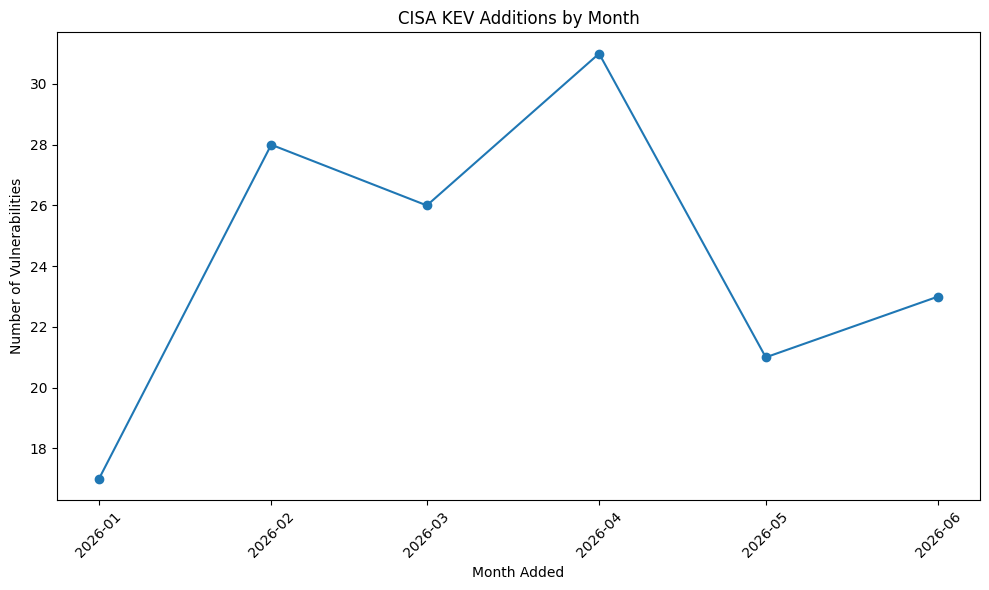

In [ ]:
# Conducting Exploratory Analysis
# First Analysis: Vulnerabilities added by Month
monthly_counts = (
    study_data
    .set_index("dateAdded")
    .resample("MS")
    .size()
    .rename("vulnerability_count")
    .reset_index()
)

monthly_counts

# Charts
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    monthly_counts["dateAdded"],
    monthly_counts["vulnerability_count"],
    marker="o"
)

ax.set_title("CISA KEV Additions by Month")
ax.set_xlabel("Month Added")
ax.set_ylabel("Number of Vulnerabilities")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig("kev_additions_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

**Key Observations**

*   April 2026 had the highest number of vulnerabilities added to the CISA Known Exploited Vulnerabilities (KEV) Catalog during the study period, with approximately 31 new entries. January had the fewest additions, with about 17 vulnerabilities.
*   The number of vulnerabilities added to the KEV Catalog fluctuated throughout the six-month study period. Additions increased sharply from January to February, decreased slightly in March, peaked in April, dropped noticeably in May, and then rose modestly in June. There is no consistent upward or downward trend across the entire period.


*   Mind you, this chart shows the number of vulnerabilities **added to the CISA KEV Catalog**, not the number of cyberattacks that occurred. Therefore, the chart should be interpreted as showing changes in KEV catalog additions rather than changes in overall attacker activity.


**Overall Assessment of First Analysis**

The fluctuations in monthly KEV additions suggest that organizations should maintain continuous vulnerability management rather than increasing defensive efforts only during months with higher catalog activity. Since vulnerabilities are added as new exploitation evidence becomes available, organizations should prioritize timely review of new KEV entries regardless of monthly volume.








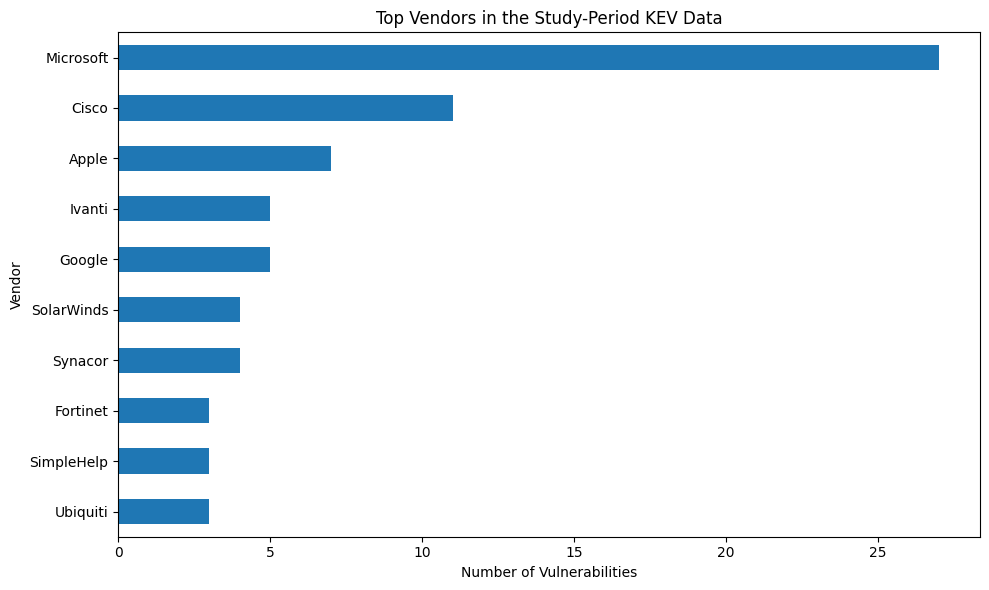

In [ ]:
# Second Analysis: Most Common Vendors
top_vendors = (
    study_data["vendorProject"]
    .value_counts()
    .head(10)
    .sort_values()
)

top_vendors

# Chart
fig, ax = plt.subplots(figsize=(10, 6))

top_vendors.plot(kind="barh", ax=ax)

ax.set_title("Top Vendors in the Study-Period KEV Data")
ax.set_xlabel("Number of Vulnerabilities")
ax.set_ylabel("Vendor")

fig.tight_layout()
fig.savefig("top_vendors.png", dpi=300, bbox_inches="tight")
plt.show()

**Note:** A vendor appearing frequently in KEV does NOT automatically mean its products are less secure. Frequency may reflect the product's popularity, attacker interest, research attention, or the organization's inclusion criteria.

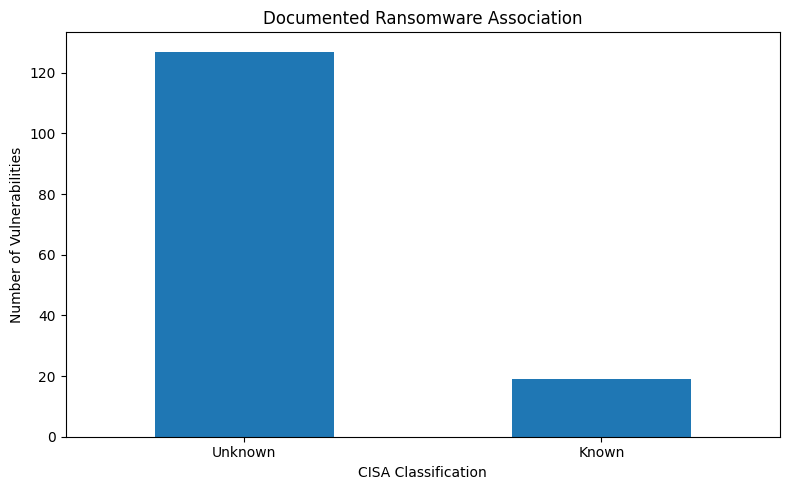

In [ ]:
# Third Analysis: Ransomware Association
# Inspecting values
study_data["knownRansomwareCampaignUse"].value_counts(dropna=False)

ransomware_counts = (
    study_data["knownRansomwareCampaignUse"]
    .fillna("Not reported")
    .value_counts()
)

# Chart
fig, ax = plt.subplots(figsize=(8, 5))

ransomware_counts.plot(kind="bar", ax=ax)

ax.set_title("Documented Ransomware Association")
ax.set_xlabel("CISA Classification")
ax.set_ylabel("Number of Vulnerabilities")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig("ransomware_association.png", dpi=300, bbox_inches="tight")
plt.show()

**Note:** I did not convert "Unknown" into "No" because unknown means that the source does not provide confirmation.

In [ ]:
# Applying Relevance to a Healthcare Setting
internet_facing_keywords = [
    "vpn",
    "gateway",
    "firewall",
    "router",
    "web server",
    "email",
    "exchange",
    "remote access",
    "file transfer",
    "collaboration",
    "application delivery",
    "network management"
]

healthcare_environment_keywords = [
    "microsoft",
    "windows",
    "vmware",
    "citrix",
    "cisco",
    "fortinet",
    "palo alto",
    "ivanti",
    "oracle",
    "adobe",
    "linux",
    "apache",
    "f5",
    "moveit",
    "confluence"
]

def combine_text_fields(row: pd.Series) -> str:
    fields = [
        "vendorProject",
        "product",
        "vulnerabilityName",
        "shortDescription"
    ]

    values = [
        str(row.get(field, ""))
        for field in fields
        if pd.notna(row.get(field, ""))
    ]

    return " ".join(values).lower()


study_data["combined_text"] = study_data.apply(combine_text_fields, axis=1)

study_data["internet_facing_relevance"] = study_data["combined_text"].apply(
    lambda text: any(keyword in text for keyword in internet_facing_keywords)
)

study_data["healthcare_environment_relevance"] = study_data["combined_text"].apply(
    lambda text: any(keyword in text for keyword in healthcare_environment_keywords)
)

study_data[
    [
        "cveID",
        "vendorProject",
        "product",
        "internet_facing_relevance",
        "healthcare_environment_relevance"
    ]
].head(20)

,cveID,vendorProject,product,internet_facing_relevance,healthcare_environment_relevance
25,CVE-2026-48558,SimpleHelp,SimpleHelp,False,False
26,CVE-2026-12569,PTC,Windchill and FlexPLM,False,False
27,CVE-2026-20230,Cisco,Unified Communications Manager,False,True
28,CVE-2025-67038,Lantronix,EDS5000,False,False
29,CVE-2026-34910,Ubiquiti,UniFi OS,False,False
30,CVE-2026-34909,Ubiquiti,UniFi OS,False,False
31,CVE-2026-34908,Ubiquiti,UniFi OS,False,False
32,CVE-2026-20253,Splunk,Enterprise,False,False
33,CVE-2026-48907,Widget Factory,Joomla Content Editor,False,False
34,CVE-2026-54420,LiteSpeed,cPanel Plugin,False,True


**Note: Relevance Limitation**

The relevance indicators are based on public product descriptions and analyst-defined
keywords. They do not represent a real asset inventory. A vulnerability may receive
a high relevance score even though the fictional organization has not been confirmed
to use the affected product.


In [ ]:
#Vulnerability Scoring
high_impact_terms = [
    "remote code execution",
    "code execution",
    "authentication bypass",
    "improper authentication",
    "command injection",
    "deserialization",
    "privilege escalation"
]

def ransomware_score(value: object) -> int:
    normalized = str(value).strip().lower()
    return 3 if normalized == "known" else 0


def high_impact_score(text: str) -> int:
    return 3 if any(term in text for term in high_impact_terms) else 0


study_data["healthcare_relevance_score"] = (
    study_data["healthcare_environment_relevance"].astype(int) * 3
)

study_data["internet_facing_score"] = (
    study_data["internet_facing_relevance"].astype(int) * 2
)

study_data["ransomware_score"] = (
    study_data["knownRansomwareCampaignUse"].apply(ransomware_score)
)

study_data["technical_impact_score"] = (
    study_data["combined_text"].apply(high_impact_score)
)

if {"dateAdded", "dueDate"}.issubset(study_data.columns):
    study_data["remediation_window_days"] = (
        study_data["dueDate"] - study_data["dateAdded"]
    ).dt.days

    study_data["remediation_urgency_score"] = (
        study_data["remediation_window_days"]
        .le(21)
        .fillna(False)
        .astype(int) * 2
    )
else:
    study_data["remediation_window_days"] = pd.NA
    study_data["remediation_urgency_score"] = 0

study_data["operational_impact_score"] = 0

score_columns = [
    "healthcare_relevance_score",
    "internet_facing_score",
    "ransomware_score",
    "technical_impact_score",
    "remediation_urgency_score",
    "operational_impact_score"
]

study_data["total_priority_score"] = study_data[score_columns].sum(axis=1)

def assign_priority(score: int) -> str:
    if score >= 13:
        return "Critical"
    if score >= 9:
        return "High"
    if score >= 5:
        return "Moderate"
    return "Low"


study_data["priority_level"] = (
    study_data["total_priority_score"].apply(assign_priority)
)

priority_columns = [
    "cveID",
    "vendorProject",
    "product",
    "vulnerabilityName",
    "knownRansomwareCampaignUse",
    "dateAdded",
    "dueDate",
    "total_priority_score",
    "priority_level"
]

ranked = (
    study_data[priority_columns]
    .sort_values(
        ["total_priority_score", "dateAdded"],
        ascending=[False, False]
    )
)

ranked.head(20)

,cveID,vendorProject,product,vulnerabilityName,knownRansomwareCampaignUse,dateAdded,dueDate,total_priority_score,priority_level
48,CVE-2026-0257,Palo Alto Networks,PAN-OS,Palo Alto Networks PAN-OS Authentication Bypas...,Known,2026-05-29,2026-06-01,13,Critical
91,CVE-2023-21529,Microsoft,Exchange Server,Microsoft Exchange Server Deserialization of U...,Known,2026-04-13,2026-04-27,13,Critical
109,CVE-2026-20131,Cisco,Secure Firewall Management Center (FMC),Cisco Secure Firewall Management Center (FMC) ...,Known,2026-03-19,2026-03-22,13,Critical
42,CVE-2026-50751,Check Point,Security Gateway,Check Point Security Gateway Improper Authenti...,Known,2026-06-08,2026-06-11,10,High
137,CVE-2026-1731,BeyondTrust,Remote Support (RS) and Privileged Remote Acce...,BeyondTrust Remote Support (RS) and Privileged...,Known,2026-02-13,2026-02-16,10,High
36,CVE-2026-35273,Oracle,PeopleSoft Enterprise PeopleTools,Oracle PeopleSoft Enterprise PeopleTools Missi...,Known,2026-06-12,2026-06-15,8,Moderate
37,CVE-2026-10520,Ivanti,Sentry,Ivanti Sentry OS Command Injection Vulnerability,Unknown,2026-06-11,2026-06-14,8,Moderate
45,CVE-2022-0492,Linux,Kernel,Linux Kernel Improper Authentication Vulnerabi...,Unknown,2026-06-02,2026-06-05,8,Moderate
64,CVE-2026-20182,Cisco,Catalyst SD-WAN,Cisco Catalyst SD-WAN Controller Authenticatio...,Unknown,2026-05-14,2026-05-17,8,Moderate
66,CVE-2026-6973,Ivanti,Endpoint Manager Mobile (EPMM),Ivanti Endpoint Manager Mobile (EPMM) Improper...,Unknown,2026-05-07,2026-05-10,8,Moderate


In [ ]:
# Assigning operational scores
manual_operational_scores = {
    "CVE-2026-0257": 3,
    "CVE-2023-21529": 3,
    "CVE-2026-20131": 3,
    "CVE-2026-50751": 3,
    "CVE-2026-1731": 3,
    "CVE-2026-35273": 2,
    "CVE-2026-10520": 2,
    "CVE-2022-0492": 2,
    "CVE-2026-20182": 3,
    "CVE-2026-6973": 2
}

study_data["operational_impact_score"] = (
    study_data["cveID"]
    .map(manual_operational_scores)
    .fillna(0)
    .astype("int64")
)

score_columns = [
    "healthcare_relevance_score",
    "internet_facing_score",
    "ransomware_score",
    "technical_impact_score",
    "remediation_urgency_score",
    "operational_impact_score"
]

study_data["total_priority_score"] = (
    study_data[score_columns]
    .fillna(0)
    .sum(axis=1)
    .astype("int64")
)

study_data["priority_level"] = (
    study_data["total_priority_score"]
    .apply(assign_priority)
)

print("Manual scores applied successfully.")

# Displaying top 10
updated_top_10 = (
    study_data[
        [
            "cveID",
            "vendorProject",
            "product",
            "dateAdded",
            "operational_impact_score",
            "total_priority_score",
            "priority_level"
        ]
    ]
    .sort_values(
        by=["total_priority_score", "dateAdded"],
        ascending=[False, False]
    )
    .head(10)
)

updated_top_10

# Checking to see if CVEs match
study_data.loc[
    study_data["cveID"].isin(manual_operational_scores.keys()),
    [
        "cveID",
        "operational_impact_score",
        "total_priority_score",
        "priority_level"
    ]
].sort_values("total_priority_score", ascending=False)

Manual scores applied successfully.


,cveID,operational_impact_score,total_priority_score,priority_level
91,CVE-2023-21529,3,16,Critical
48,CVE-2026-0257,3,16,Critical
109,CVE-2026-20131,3,16,Critical
42,CVE-2026-50751,3,13,Critical
137,CVE-2026-1731,3,13,Critical
64,CVE-2026-20182,3,11,High
37,CVE-2026-10520,2,10,High
36,CVE-2026-35273,2,10,High
45,CVE-2022-0492,2,10,High
66,CVE-2026-6973,2,10,High


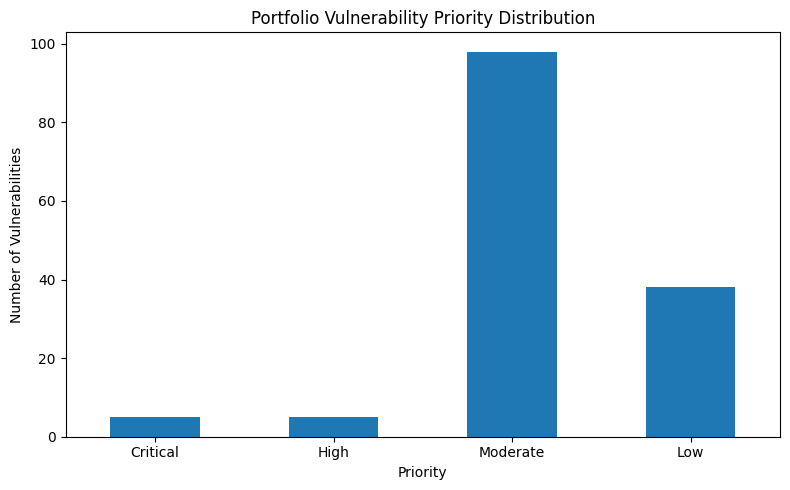

In [ ]:
# Priority Visuals
priority_order = ["Critical", "High", "Moderate", "Low"]

priority_counts = (
    study_data["priority_level"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

priority_counts.plot(kind="bar", ax=ax)

ax.set_title("Portfolio Vulnerability Priority Distribution")
ax.set_xlabel("Priority")
ax.set_ylabel("Number of Vulnerabilities")
ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig("priority_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Note:** These categories result from my portfolio's scoring, not an official CISA severity classification!

In [ ]:
# processing data
output_columns = [
    "cveID",
    "vendorProject",
    "product",
    "vulnerabilityName",
    "dateAdded",
    "dueDate",
    "knownRansomwareCampaignUse",
    "healthcare_relevance_score",
    "internet_facing_score",
    "ransomware_score",
    "technical_impact_score",
    "remediation_urgency_score",
    "operational_impact_score",
    "total_priority_score",
    "priority_level"
]

processed_output = (
    study_data[output_columns]
    .sort_values(
        ["total_priority_score", "dateAdded"],
        ascending=[False, False]
    )
)

processed_output.to_csv(
    "prioritized_kev_2026.csv",
    index=False
)

processed_output.head()

,cveID,vendorProject,product,vulnerabilityName,dateAdded,dueDate,knownRansomwareCampaignUse,healthcare_relevance_score,internet_facing_score,ransomware_score,technical_impact_score,remediation_urgency_score,operational_impact_score,total_priority_score,priority_level
48,CVE-2026-0257,Palo Alto Networks,PAN-OS,Palo Alto Networks PAN-OS Authentication Bypas...,2026-05-29,2026-06-01,Known,3,2,3,3,2,3,16,Critical
91,CVE-2023-21529,Microsoft,Exchange Server,Microsoft Exchange Server Deserialization of U...,2026-04-13,2026-04-27,Known,3,2,3,3,2,3,16,Critical
109,CVE-2026-20131,Cisco,Secure Firewall Management Center (FMC),Cisco Secure Firewall Management Center (FMC) ...,2026-03-19,2026-03-22,Known,3,2,3,3,2,3,16,Critical
42,CVE-2026-50751,Check Point,Security Gateway,Check Point Security Gateway Improper Authenti...,2026-06-08,2026-06-11,Known,0,2,3,3,2,3,13,Critical
137,CVE-2026-1731,BeyondTrust,Remote Support (RS) and Privileged Remote Acce...,BeyondTrust Remote Support (RS) and Privileged...,2026-02-13,2026-02-16,Known,0,2,3,3,2,3,13,Critical


# Final Threat Intelligence Assessment

## Dataset Summary

The final study dataset contains **146 vulnerabilities** from **69 vendors** added to the CISA Known Exploited Vulnerabilities Catalog between January 1 and June 30, 2026.

The portfolio scoring model classified:

- **5 Critical**
- **5 High**
- **98 Moderate**
- **38 Low**

A total of **19 vulnerabilities** were marked by CISA as having known ransomware campaign use.

These categories reflect this project's analyst-defined prioritization model. They are not official CISA severity ratings.


In [ ]:
# Display the final top 10 after manual operational-impact review.
final_top_10_columns = [
    "cveID",
    "vendorProject",
    "product",
    "vulnerabilityName",
    "knownRansomwareCampaignUse",
    "dateAdded",
    "dueDate",
    "operational_impact_score",
    "total_priority_score",
    "priority_level"
]

final_top_10 = (
    study_data
    .sort_values(
        ["total_priority_score", "dateAdded"],
        ascending=[False, False]
    )
    [final_top_10_columns]
    .head(10)
    .reset_index(drop=True)
)

final_top_10


## Selected Priority Case Studies

The three highest-scoring vulnerabilities were selected for deeper research because each received a final score of **16** and affects high-value enterprise infrastructure.

| CVE | Product | Primary concern | Final priority |
|---|---|---|---|
| CVE-2026-0257 | Palo Alto Networks PAN-OS GlobalProtect | Authentication bypass enabling an unauthorized VPN connection | Critical |
| CVE-2023-21529 | Microsoft Exchange Server | Authenticated network-based remote code execution | Critical |
| CVE-2026-20131 | Cisco Secure Firewall Management Center | Unauthenticated remote code execution as root | Critical |

The selection provides coverage across remote access, enterprise communications, and centralized network-security management.


## Case Study 1: CVE-2026-0257 — PAN-OS GlobalProtect

### Key Judgment

CVE-2026-0257 is a high-priority perimeter risk because an unauthenticated attacker may establish an unauthorized VPN connection when vulnerable GlobalProtect configuration conditions are present.

### Potential Healthcare Impact

If Northstar Regional Health used an affected configuration, exploitation could bypass an important remote-access control, provide connectivity to internal networks, interrupt remote clinical support or IT administration during emergency remediation, and create opportunities for follow-on compromise.

### Defensive Priorities

1. Verify whether PAN-OS and GlobalProtect are deployed.
2. Identify affected versions and configuration conditions.
3. Upgrade to a vendor-fixed release.
4. Review GlobalProtect authentication and VPN logs.
5. Investigate suspicious or unauthorized VPN sessions.

### Confidence

**High confidence** in the vulnerability behavior and remediation based on the vendor advisory. **Moderate confidence** in organization-specific impact because Northstar Regional Health is fictional and has no verified asset inventory.


## Case Study 2: CVE-2023-21529 — Microsoft Exchange Server

### Key Judgment

CVE-2023-21529 is a priority enterprise-messaging risk because an authenticated network attacker can exploit unsafe deserialization to execute code on vulnerable Microsoft Exchange Server systems.

### Potential Healthcare Impact

Compromise could disrupt email used for clinical coordination and administrative operations, expose sensitive communications or attachments, execute attacker-controlled code on a trusted server, and support movement toward other enterprise systems.

### Defensive Priorities

1. Inventory all on-premises Exchange Server installations.
2. Confirm cumulative and security update levels.
3. Apply Microsoft-provided fixes.
4. Review Exchange, Windows, identity, and management logs.
5. Isolate affected systems and reset credentials when compromise is suspected.

### Confidence

**High confidence** that the vulnerability enables authenticated network-based remote code execution and is actively exploited. **Moderate confidence** in the precise operational scenario because public reporting does not provide complete campaign details.


## Case Study 3: CVE-2026-20131 — Cisco Secure Firewall Management Center

### Key Judgment

CVE-2026-20131 is a severe centralized security-administration risk because an unauthenticated remote attacker can exploit the web management interface and execute arbitrary Java code as root.

### Potential Healthcare Impact

Successful exploitation could compromise centralized firewall management, alter security policies, weaken segmentation between facilities or operational environments, reduce network visibility, and require broad validation or restoration work.

### Defensive Priorities

1. Identify all Secure Firewall Management Center installations and versions.
2. Upgrade to a Cisco-fixed release.
3. Remove unnecessary public access to management interfaces.
4. Restrict administration to dedicated management networks and trusted hosts.
5. Review web-interface, process, authentication, and policy-change logs.
6. Validate firewall policies and administrative accounts after remediation.

### Confidence

**High confidence** in the technical impact, exploitation status, and remediation based on Cisco's advisory. **Moderate confidence** in Northstar-specific exposure because no real inventory or architecture is available.


# MITRE ATT&CK Mapping

ATT&CK mappings are intentionally limited to techniques supported by the exploitation mechanism or authoritative reporting. Post-compromise behavior is not added merely because it is theoretically possible.

| Vulnerability | Tactic | Technique | Evidence Status | Rationale |
|---|---|---|---|---|
| CVE-2026-0257 | Initial Access | T1190 — Exploit Public-Facing Application | Assessed with high confidence | An externally reachable GlobalProtect portal or gateway is exploited to establish unauthorized network access. |
| CVE-2023-21529 | Lateral Movement | T1210 — Exploitation of Remote Services | Assessed with moderate confidence | The flaw is exploited over a network service and requires an authenticated attacker. Public exposure is not assumed. |
| CVE-2026-20131 | Initial Access | T1190 — Exploit Public-Facing Application | Conditional assessment | Applies when the Cisco web management interface is exposed to the internet. |
| CVE-2026-20131 | Lateral Movement | T1210 — Exploitation of Remote Services | Assessed | Applies when the interface is reachable only through an internal or administrative network. |

An ATT&CK Navigator JSON layer is included in the GitHub project package under `attack-navigator/healthcare-threat-layer.json`.


# Executive-Level Findings

## Key Judgment

Northstar Regional Health's most consequential near-term vulnerability exposure is likely concentrated in externally reachable and centrally managed infrastructure. The three highest-priority vulnerabilities affect remote access, enterprise email, and centralized firewall management. Successful exploitation could provide access to trusted systems or disrupt communications and network-security controls across multiple sites.

## Recommended 30-Day Actions

1. Match the priority products against an authoritative asset inventory.
2. Confirm installed versions and configuration-specific exposure.
3. Apply vendor fixes and track remediation to closure.
4. Review remote-access, Exchange, firewall-management, and identity logs.
5. Restrict management interfaces to dedicated administrative networks.
6. Validate segmentation and privileged accounts after remediation.
7. Test contingency procedures for the loss of email, remote access, or firewall management.

## Analytical Limitations

- Northstar Regional Health is fictional.
- No real asset inventory, scanner results, logs, architecture diagrams, or business-impact assessments were used.
- Keyword-based relevance does not prove that a product is deployed.
- The scoring framework is educational and has not been independently validated.
- A KEV addition date does not necessarily represent the date exploitation began.
- An `Unknown` ransomware classification was not interpreted as proof that ransomware use did not occur.


In [ ]:
# Create final summary tables for the GitHub project.
summary_table = pd.DataFrame(
    {
        "measure": [
            "Records analyzed",
            "Unique vendors",
            "Critical findings",
            "High findings",
            "Moderate findings",
            "Low findings",
            "Known ransomware association",
        ],
        "result": [
            len(study_data),
            study_data["vendorProject"].nunique(),
            int((study_data["priority_level"] == "Critical").sum()),
            int((study_data["priority_level"] == "High").sum()),
            int((study_data["priority_level"] == "Moderate").sum()),
            int((study_data["priority_level"] == "Low").sum()),
            int((study_data["knownRansomwareCampaignUse"] == "Known").sum()),
        ],
    }
)

priority_case_studies = final_top_10.head(3).copy()

summary_table.to_csv("analysis_summary.csv", index=False)
priority_case_studies.to_csv("priority_case_studies.csv", index=False)

print("Created analysis_summary.csv")
print("Created priority_case_studies.csv")
summary_table


# Source Register

Authoritative sources used in the accompanying reports include:

- CISA Known Exploited Vulnerabilities Catalog
- Palo Alto Networks security advisory for CVE-2026-0257
- Microsoft Security Response Center and NIST NVD records for CVE-2023-21529
- Cisco security advisory for CVE-2026-20131
- MITRE ATT&CK techniques T1190 and T1210
- MITRE ATT&CK Navigator

The complete URLs are recorded in `docs/source-register.md` in the GitHub project package.


# Portfolio Deliverables

The completed project package contains:

- The processed vulnerability dataset
- This reproducible analysis notebook
- Executive and technical threat intelligence reports
- Vulnerability research profiles
- Analytical methodology
- Source register
- MITRE ATT&CK Navigator layer
- Portfolio charts
- GitHub README

Before publishing, replace the author and LinkedIn placeholders in `README.md`.


In [ ]:
# Optional Colab download helper.
# Run this only after the notebook has completed successfully.

from pathlib import Path

created_files = [
    Path("prioritized_kev_2026.csv"),
    Path("analysis_summary.csv"),
    Path("priority_case_studies.csv"),
    Path("kev_additions_by_month.png"),
    Path("top_vendors.png"),
    Path("ransomware_association.png"),
    Path("priority_distribution.png"),
]

print("Files created by this notebook:")
for path in created_files:
    print(f"- {path} {'✓' if path.exists() else '(not found yet)'}")

# In Google Colab, uncomment the following lines to download a file:
# from google.colab import files
# files.download("prioritized_kev_2026.csv")
